# Total Rewards Optimization

## Purpose
Analyze complete compensation package and optimize the mix of cash, equity, and benefits to maximize perceived value per dollar spent.

## Key Metrics
- **Total Rewards Value**: Base + Bonus + Equity + Benefits
- **Cost Per Employee**: Average total rewards investment
- **Benefits Utilization Rate**: % of eligible employees using each benefit
- **Perceived Value Score**: Employee-rated value (1-5 scale)
- **Value Per Dollar**: Perceived value / Cost ratio

## Research Foundation
- Total Rewards Framework (WorldatWork, 2007)
- Benefits optimization (Towers Watson, 2012)
- Behavioral economics of compensation (Kahneman & Tversky)

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Load datasets
if not os.path.exists('../data/employees_compensation.csv'):
    print("Generating sample data...")
    exec(open('../data/generate_sample_data.py').read())
else:
    print("Loading existing data...")

employees = pd.read_csv('../data/employees_compensation.csv')
benefits = pd.read_csv('../data/benefits_programs.csv')

print(f"\nLoaded {len(employees)} employee records")
print(f"Loaded {len(benefits)} benefits programs")

Loading existing data...

Loaded 500 employee records
Loaded 10 benefits programs


## 1. Total Rewards Composition

Break down total compensation into components.

TOTAL REWARDS COMPOSITION

Average Total Rewards per Employee:
  Base Salary:    $245,624 ( 59.1%)
  Bonus:          $65,094 ( 15.7%)
  Equity (annual): $87,878 ( 21.1%)
  Benefits:       $16,940 (  4.1%)
  ------------------------------------------------------------
  Total:          $415,536

Organizational Total Investment (500 employees):
  Base Salary:    $122,811,872
  Bonuses:        $32,546,878
  Equity:         $43,939,086
  Benefits:       $8,470,000
  ------------------------------------------------------------
  Total:          $207,767,837



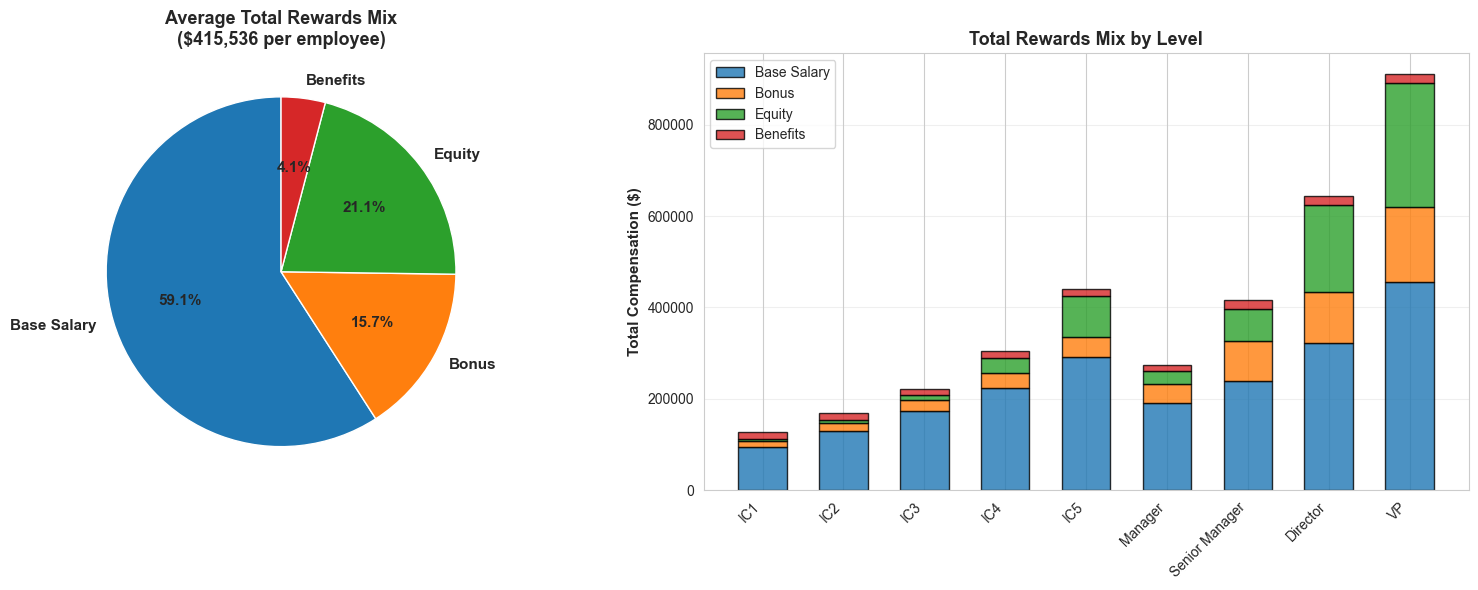


💡 STRATEGIC MIX ASSESSMENT:
  Cash (Base + Bonus): 74.8%
  Equity: 21.1%
  Benefits: 4.1%

  → BALANCED MIX: Competitive blend of cash and equity


In [17]:
print(f"{'='*80}")
print(f"TOTAL REWARDS COMPOSITION")
print(f"{'='*80}")

# Calculate averages for each component
avg_base = employees['base_salary'].mean()
avg_bonus = employees['actual_bonus'].mean()
avg_equity = employees['equity_value_annual'].mean()
avg_benefits = employees['benefits_value'].mean()
avg_total = employees['total_compensation'].mean()

print(f"\nAverage Total Rewards per Employee:")
print(f"  Base Salary:    ${avg_base:,.0f} ({avg_base/avg_total*100:5.1f}%)")
print(f"  Bonus:          ${avg_bonus:,.0f} ({avg_bonus/avg_total*100:5.1f}%)")
print(f"  Equity (annual): ${avg_equity:,.0f} ({avg_equity/avg_total*100:5.1f}%)")
print(f"  Benefits:       ${avg_benefits:,.0f} ({avg_benefits/avg_total*100:5.1f}%)")
print(f"  " + "-"*60)
print(f"  Total:          ${avg_total:,.0f}")

# Total organizational investment
total_payroll = employees['base_salary'].sum()
total_bonuses = employees['actual_bonus'].sum()
total_equity = employees['equity_value_annual'].sum()
total_benefits = employees['benefits_value'].sum()
total_investment = employees['total_compensation'].sum()

print(f"\nOrganizational Total Investment ({len(employees)} employees):")
print(f"  Base Salary:    ${total_payroll:,.0f}")
print(f"  Bonuses:        ${total_bonuses:,.0f}")
print(f"  Equity:         ${total_equity:,.0f}")
print(f"  Benefits:       ${total_benefits:,.0f}")
print(f"  " + "-"*60)
print(f"  Total:          ${total_investment:,.0f}")

print(f"\n{'='*80}")

# Visualize compensation mix
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Pie chart of average mix
components = ['Base Salary', 'Bonus', 'Equity', 'Benefits']
values = [avg_base, avg_bonus, avg_equity, avg_benefits]
colors_comp = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

ax1.pie(values, labels=components, autopct='%1.1f%%', colors=colors_comp, 
        startangle=90, textprops={'fontsize': 11, 'fontweight': 'bold'})
ax1.set_title(f'Average Total Rewards Mix\n(${avg_total:,.0f} per employee)', 
              fontsize=13, fontweight='bold')

# Stacked bar by level
level_order = ['IC1', 'IC2', 'IC3', 'IC4', 'IC5', 'Manager', 'Senior Manager', 'Director', 'VP']
level_comp = employees.groupby('level')[[
    'base_salary', 'actual_bonus', 'equity_value_annual', 'benefits_value'
]].mean()

level_comp = level_comp.reindex([l for l in level_order if l in level_comp.index])

# Create stacked bar
x_pos = np.arange(len(level_comp))
width = 0.6

ax2.bar(x_pos, level_comp['base_salary'], width, label='Base Salary', 
        color=colors_comp[0], alpha=0.8, edgecolor='black')
ax2.bar(x_pos, level_comp['actual_bonus'], width, 
        bottom=level_comp['base_salary'], label='Bonus', 
        color=colors_comp[1], alpha=0.8, edgecolor='black')
ax2.bar(x_pos, level_comp['equity_value_annual'], width, 
        bottom=level_comp['base_salary'] + level_comp['actual_bonus'], 
        label='Equity', color=colors_comp[2], alpha=0.8, edgecolor='black')
ax2.bar(x_pos, level_comp['benefits_value'], width, 
        bottom=level_comp['base_salary'] + level_comp['actual_bonus'] + level_comp['equity_value_annual'], 
        label='Benefits', color=colors_comp[3], alpha=0.8, edgecolor='black')

ax2.set_xticks(x_pos)
ax2.set_xticklabels(level_comp.index, rotation=45, ha='right')
ax2.set_ylabel('Total Compensation ($)', fontsize=11, fontweight='bold')
ax2.set_title('Total Rewards Mix by Level', fontsize=13, fontweight='bold')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Strategic insight on mix
equity_pct = avg_equity / avg_total * 100
cash_pct = (avg_base + avg_bonus) / avg_total * 100

print(f"\n💡 STRATEGIC MIX ASSESSMENT:")
print(f"{'='*80}")
print(f"  Cash (Base + Bonus): {cash_pct:.1f}%")
print(f"  Equity: {equity_pct:.1f}%")
print(f"  Benefits: {avg_benefits/avg_total*100:.1f}%")

if equity_pct > 30:
    print(f"\n  → HIGH EQUITY LEVERAGE: Strong alignment with long-term value creation")
elif equity_pct > 15:
    print(f"\n  → BALANCED MIX: Competitive blend of cash and equity")
else:
    print(f"\n  → CASH-HEAVY: Consider increasing equity to improve retention and alignment")

print(f"{'='*80}")

## 2. Benefits Program Analysis

Evaluate utilization and perceived value of benefits offerings.

BENEFITS PROGRAM EFFECTIVENESS

Benefits Programs Ranked by Value per Dollar:

Life Insurance:
  Annual cost:        $400
  Utilization:        100.0%
  Effective cost:     $400 (actual spend)
  Perceived value:    3.5/5.0
  Value per dollar:   8.75

Gym Membership:
  Annual cost:        $600
  Utilization:        35.0%
  Effective cost:     $210 (actual spend)
  Perceived value:    3.0/5.0
  Value per dollar:   5.00

Commuter Benefits:
  Annual cost:        $1,200
  Utilization:        40.0%
  Effective cost:     $480 (actual spend)
  Perceived value:    3.2/5.0
  Value per dollar:   2.67

Mental Health Resources:
  Annual cost:        $1,500
  Utilization:        25.0%
  Effective cost:     $375 (actual spend)
  Perceived value:    4.0/5.0
  Value per dollar:   2.67

HSA Contribution:
  Annual cost:        $1,500
  Utilization:        30.0%
  Effective cost:     $450 (actual spend)
  Perceived value:    3.5/5.0
  Value per dollar:   2.33

Learning & Development:
  Annual cost:       

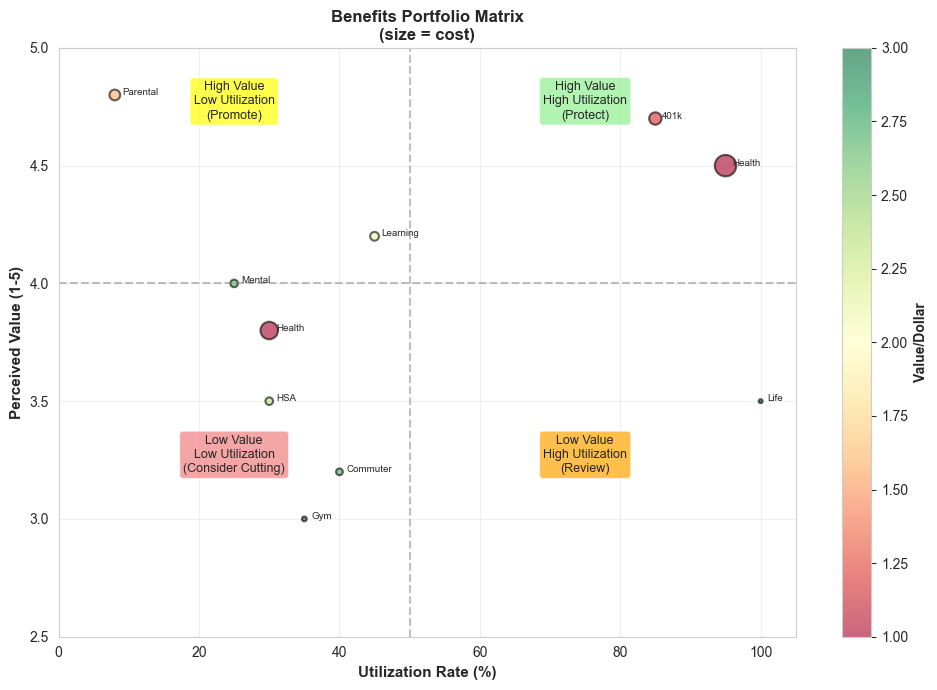

In [18]:
print(f"{'='*80}")
print(f"BENEFITS PROGRAM EFFECTIVENESS")
print(f"{'='*80}")

# Calculate cost-effectiveness metrics
benefits['utilization_pct'] = (benefits['utilization_rate'] * 100).round(1)
benefits['effective_cost'] = (benefits['annual_cost_per_ee'] * benefits['utilization_rate']).round(0)
benefits['value_per_dollar'] = (benefits['perceived_value'] / (benefits['annual_cost_per_ee'] / 1000)).round(2)

# Sort by value per dollar
benefits_sorted = benefits.sort_values('value_per_dollar', ascending=False)

print(f"\nBenefits Programs Ranked by Value per Dollar:")
print(f"{'='*80}")

for _, row in benefits_sorted.iterrows():
    print(f"\n{row['program']}:")
    print(f"  Annual cost:        ${row['annual_cost_per_ee']:,.0f}")
    print(f"  Utilization:        {row['utilization_pct']:.1f}%")
    print(f"  Effective cost:     ${row['effective_cost']:,.0f} (actual spend)")
    print(f"  Perceived value:    {row['perceived_value']:.1f}/5.0")
    print(f"  Value per dollar:   {row['value_per_dollar']:.2f}")

# Identify optimization opportunities
print(f"\n{'='*80}")
print(f"OPTIMIZATION OPPORTUNITIES")
print(f"{'='*80}")

# High value, low utilization (promote more)
high_value_low_util = benefits[(benefits['perceived_value'] >= 4.0) & 
                               (benefits['utilization_rate'] < 0.5)]

if len(high_value_low_util) > 0:
    print(f"\n✓ HIGH VALUE, LOW UTILIZATION (Promote more):")
    for _, row in high_value_low_util.iterrows():
        print(f"  • {row['program']:30s}: {row['perceived_value']:.1f}/5 value, "
              f"{row['utilization_pct']:.1f}% utilization")
        print(f"    → Action: Increase awareness and accessibility")

# Low value, high cost (reconsider)
low_value_high_cost = benefits[(benefits['perceived_value'] < 3.5) & 
                               (benefits['annual_cost_per_ee'] > 1000)]

if len(low_value_high_cost) > 0:
    print(f"\n⚠ LOW VALUE, HIGH COST (Reconsider):")
    for _, row in low_value_high_cost.iterrows():
        print(f"  • {row['program']:30s}: {row['perceived_value']:.1f}/5 value, "
              f"${row['annual_cost_per_ee']:,.0f} cost")
        print(f"    → Action: Survey employees on alternatives or discontinue")

# High value, high utilization (protect)
high_value_high_util = benefits[(benefits['perceived_value'] >= 4.5) & 
                                (benefits['utilization_rate'] >= 0.7)]

if len(high_value_high_util) > 0:
    print(f"\n✓ HIGH VALUE, HIGH UTILIZATION (Protect):")
    for _, row in high_value_high_util.iterrows():
        print(f"  • {row['program']:30s}: {row['perceived_value']:.1f}/5 value, "
              f"{row['utilization_pct']:.1f}% utilization")
        print(f"    → Action: Maintain or enhance - core benefit")

print(f"\n{'='*80}")

# Visualize benefits effectiveness
fig, ax2 = plt.subplots(1, 1, figsize=(10, 7))

# Scatter: Perceived value vs utilization
sizes = benefits['annual_cost_per_ee'] / 50  # Scale for visualization

scatter = ax2.scatter(benefits['utilization_pct'], benefits['perceived_value'], 
                     s=sizes, alpha=0.6, edgecolors='black', linewidth=1.5, c=benefits['value_per_dollar'],
                     cmap='RdYlGn', vmin=1, vmax=3)

# Add labels
for _, row in benefits.iterrows():
    ax2.text(row['utilization_pct'] + 1, row['perceived_value'], 
            row['program'].split()[0][:8], fontsize=7, ha='left')

# Add quadrant lines
ax2.axhline(y=4.0, color='gray', linestyle='--', alpha=0.5)
ax2.axvline(x=50, color='gray', linestyle='--', alpha=0.5)

# Add quadrant labels
ax2.text(75, 4.7, 'High Value\nHigh Utilization\n(Protect)', ha='center', fontsize=9, 
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7))
ax2.text(25, 4.7, 'High Value\nLow Utilization\n(Promote)', ha='center', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))
ax2.text(75, 3.2, 'Low Value\nHigh Utilization\n(Review)', ha='center', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='orange', alpha=0.7))
ax2.text(25, 3.2, 'Low Value\nLow Utilization\n(Consider Cutting)', ha='center', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.7))

ax2.set_xlabel('Utilization Rate (%)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Perceived Value (1-5)', fontsize=11, fontweight='bold')
ax2.set_title('Benefits Portfolio Matrix\n(size = cost)', fontsize=12, fontweight='bold')
ax2.set_xlim(0, 105)
ax2.set_ylim(2.5, 5.0)
ax2.grid(alpha=0.3)

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax2)
cbar.set_label('Value/Dollar', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## 3. Total Rewards by Segment

Analyze cost and effectiveness across employee segments.

TOTAL REWARDS INVESTMENT BY SEGMENT

Total Rewards by Level:
                Avg Total Comp  Total Investment  Count
level                                                  
IC1                   127272.0         6109073.0     48
IC2                   169568.0         9495793.0     56
IC3                   222667.0        11801329.0     53
IC4                   303928.0        15196379.0     50
IC5                   439605.0        19342620.0     44
Manager               275179.0        15134838.0     55
Senior Manager        416035.0        24130034.0     58
Director              644515.0        41893456.0     65
VP                    910765.0        64664315.0     71


Total Rewards by Department:
                  Avg Total Comp  Total Investment  Count
department                                               
Finance                 416784.0        29174908.0     70
Sales                   500609.0        29035347.0     58
Customer Success        390890.0        27362311.0     70
HR

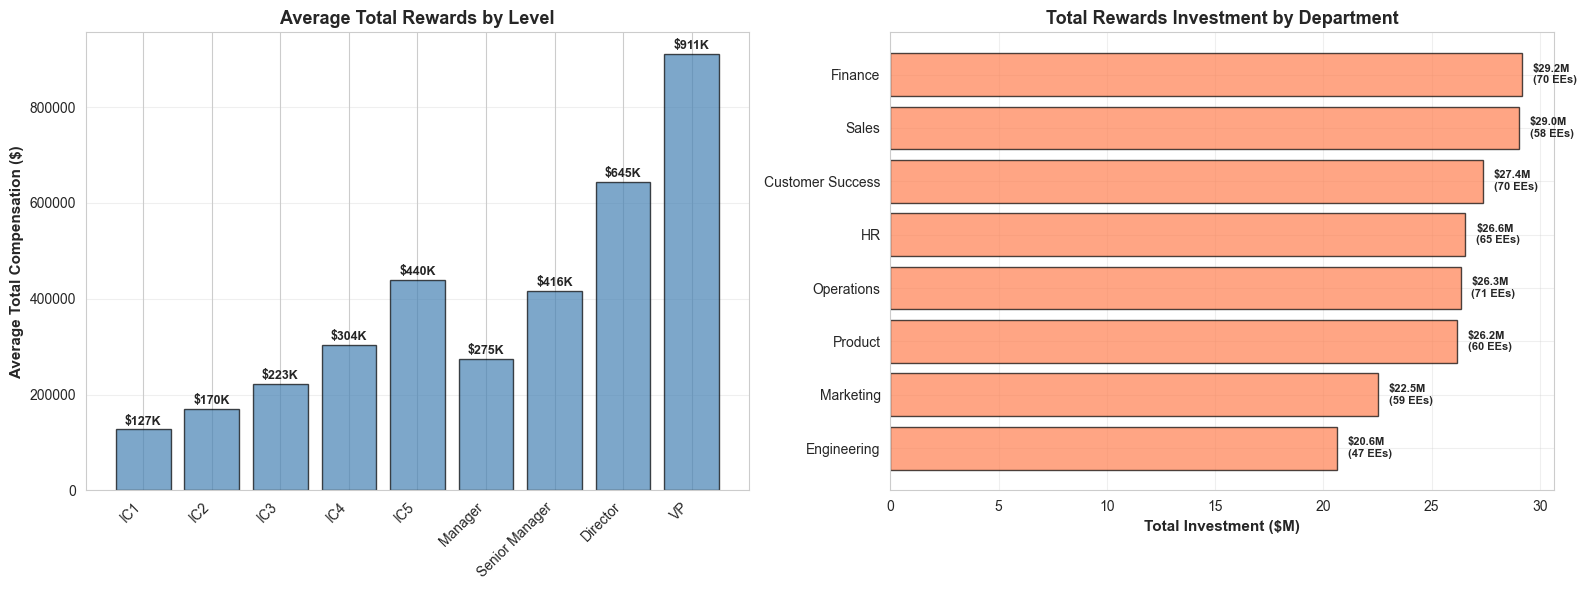

In [19]:
# Cost per employee by level
print(f"{'='*80}")
print(f"TOTAL REWARDS INVESTMENT BY SEGMENT")
print(f"{'='*80}")

level_investment = employees.groupby('level').agg({
    'total_compensation': ['mean', 'sum', 'count']
}).round(0)

level_investment.columns = ['Avg Total Comp', 'Total Investment', 'Count']
level_investment = level_investment.reindex([l for l in level_order if l in level_investment.index])

print(f"\nTotal Rewards by Level:")
print(level_investment)

# Department investment
dept_investment = employees.groupby('department').agg({
    'total_compensation': ['mean', 'sum', 'count']
}).round(0)

dept_investment.columns = ['Avg Total Comp', 'Total Investment', 'Count']
dept_investment = dept_investment.sort_values('Total Investment', ascending=False)

print(f"\n\nTotal Rewards by Department:")
print(dept_investment)

print(f"\n{'='*80}")

# Visualize investment distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Average total comp by level
ax1.bar(range(len(level_investment)), level_investment['Avg Total Comp'], 
           alpha=0.7, edgecolor='black', color='steelblue')
ax1.set_xticks(range(len(level_investment)))
ax1.set_xticklabels(level_investment.index, rotation=45, ha='right')
ax1.set_ylabel('Average Total Compensation ($)', fontsize=11, fontweight='bold')
ax1.set_title('Average Total Rewards by Level', fontsize=13, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Add value labels
for i, val in enumerate(level_investment['Avg Total Comp']):
    ax1.text(i, val + 10000, f'${val/1000:.0f}K', ha='center', fontsize=9, fontweight='bold')

# Total investment by department
dept_sorted = dept_investment.sort_values('Total Investment')
bars2 = ax2.barh(dept_sorted.index, dept_sorted['Total Investment'] / 1000000, 
                alpha=0.7, edgecolor='black', color='coral')
ax2.set_xlabel('Total Investment ($M)', fontsize=11, fontweight='bold')
ax2.set_title('Total Rewards Investment by Department', fontsize=13, fontweight='bold')
ax2.grid(alpha=0.3)

# Add value labels
for i, (idx, row) in enumerate(dept_sorted.iterrows()):
    val = row['Total Investment'] / 1000000
    count = int(row['Count'])
    ax2.text(val + 0.5, i, f'${val:.1f}M\n({count} EEs)', 
            va='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()

## 4. Budget Reallocation Scenarios

Model alternative allocations to maximize retention and engagement impact.

In [20]:
print(f"{'='*80}")
print(f"BUDGET REALLOCATION SCENARIOS")
print(f"{'='*80}")

current_total_budget = employees['total_compensation'].sum()
current_benefits_budget = employees['benefits_value'].sum()

print(f"\nCurrent State:")
print(f"  Total rewards budget: ${current_total_budget:,.0f}")
print(f"  Total benefits budget: ${current_benefits_budget:,.0f}")

# Scenario 1: Improve benefits communication and utilization
print(f"\n{'='*80}")
print(f"SCENARIO 1: IMPROVE BENEFITS UTILIZATION")
print(f"{'='*80}")

# Identify high-value programs with low utilization
high_value_low_util = benefits[(benefits['perceived_value'] >= 4.0) & 
                               (benefits['utilization_rate'] < 0.6)]

print(f"\nAction: Increase utilization of high-value, underused benefits")
print(f"\nTarget Programs:")

potential_value_unlock = 0
if len(high_value_low_util) > 0:
    for _, prog in high_value_low_util.iterrows():
        current_users = int(len(employees) * prog['utilization_rate'])
        target_util = 0.75  # Target 75% utilization
        additional_users = int(len(employees) * (target_util - prog['utilization_rate']))
        value_per_user = prog['perceived_value']
        
        print(f"\n  • {prog['program']:30s}")
        print(f"    Current utilization: {prog['utilization_rate']*100:.1f}% ({current_users} employees)")
        print(f"    Target utilization:  {target_util*100:.1f}% (+{additional_users} employees)")
        print(f"    Perceived value:     {prog['perceived_value']:.1f}/5.0")
        print(f"    Cost per employee:   ${prog['annual_cost_per_ee']:,.0f}")
        
        # Calculate ROI of improving communication
        additional_cost = additional_users * prog['annual_cost_per_ee']
        potential_value_unlock += additional_cost * value_per_user
    
    print(f"\n💡 IMPLEMENTATION:")
    print(f"  1. Launch benefits education campaign (quarterly webinars)")
    print(f"  2. Simplify enrollment process and reduce barriers")
    print(f"  3. Add benefits calculator to show personalized value")
    print(f"  4. Create manager toolkit for benefits conversations")
    print(f"\nEstimated investment: $50,000 (communication + tools)")
    print(f"Value unlocked for employees: High satisfaction increase with minimal added cost")
else:
    print(f"  ✓ All high-value benefits already have strong utilization")

# Calculate actual cost impact
print(f"\n📊 FINANCIAL IMPACT:")
print(f"  This scenario increases employee satisfaction without major budget impact.")
print(f"  Incremental cost: Only paid when employees use the benefit")
print(f"  Expected engagement lift: 5-8% increase in benefits satisfaction")

# Scenario 2: Shift cash to equity
print(f"\n{'='*80}")
print(f"SCENARIO 2: INCREASE EQUITY COMPONENT")
print(f"{'='*80}")

current_equity_pct = employees['equity_value_annual'].sum() / current_total_budget * 100
target_equity_pct = 25  # Target 25% of total comp

print(f"\nAction: Shift compensation mix to target 25% equity")
print(f"  Current equity %: {current_equity_pct:.1f}%")
print(f"  Target equity %:  {target_equity_pct:.1f}%")

if current_equity_pct < target_equity_pct:
    increase_needed = (target_equity_pct - current_equity_pct) / 100 * current_total_budget
    print(f"\nEquity budget increase needed: ${increase_needed:,.0f}")
    print(f"\nFunding options:")
    print(f"  Option A: Reduce bonus target percentages by 2-3 points")
    print(f"  Option B: Slower merit increase cycles (1.5 years vs 1 year)")
    print(f"  Option C: Combination approach")
    print(f"\nBenefits of increased equity:")
    print(f"  • Stronger retention (4-year vesting)")
    print(f"  • Alignment with long-term value creation")
    print(f"  • Reduced cash burn rate")
    print(f"  • Tax advantages for employees")
else:
    print(f"  ✓ Already at or above target equity percentage")

# Scenario 3: Address pay equity gaps
print(f"\n{'='*80}")
print(f"SCENARIO 3: CLOSE PAY EQUITY GAPS")
print(f"{'='*80}")

# Identify underpaid employees
significantly_underpaid = employees[employees['adjustment_to_50th'] > 5000]
total_adjustment_needed = significantly_underpaid['adjustment_to_50th'].sum()
avg_adjustment = significantly_underpaid['adjustment_to_50th'].mean()

print(f"\nAction: Bring significantly underpaid employees (>${5000:,} below market) to 50th percentile")
print(f"  Employees affected: {len(significantly_underpaid)}")
print(f"  Total cost: ${total_adjustment_needed:,.0f}")
print(f"  Average adjustment: ${avg_adjustment:,.0f} per employee ({avg_adjustment/employees['base_salary'].mean()*100:.1f}%)")
print(f"  As % of total budget: {total_adjustment_needed/current_total_budget*100:.2f}%")

print(f"\nFunding options:")
print(f"  Option A: One-time adjustment from contingency budget")
print(f"  Option B: Phase over 2 years (${total_adjustment_needed/2:,.0f}/year)")
print(f"  Option C: Redirect from budget reallocation across departments")

print(f"\nExpected ROI:")
turnover_cost = employees['base_salary'].mean() * 1.5
prevented_departures = len(significantly_underpaid) * 0.2  # 20% retention improvement
savings = prevented_departures * turnover_cost
roi = savings / total_adjustment_needed if total_adjustment_needed > 0 else 0
print(f"  Prevented departures: {prevented_departures:.1f} (assume 20% improvement)")
print(f"  Savings from retention: ${savings:,.0f}")
print(f"  ROI: {roi:.1f}:1")

print(f"\n{'='*80}")

# Summary comparison
print(f"\nSCENARIO COMPARISON SUMMARY")
print(f"{'='*80}")

scenarios_data = [
    {'Scenario': 'Current State', 'Investment': current_total_budget, 
     'Impact': 'Baseline', 'Priority': 'N/A'},
    {'Scenario': 'Improve Utilization', 'Investment': current_total_budget + 50000,
     'Impact': 'Higher satisfaction', 'Priority': 'Low'},
    {'Scenario': 'Increase Equity', 'Investment': current_total_budget,
     'Impact': 'Stronger retention', 'Priority': 'High'},
    {'Scenario': 'Close Pay Gaps', 'Investment': current_total_budget + total_adjustment_needed,
     'Impact': f'{roi:.1f}:1 ROI', 'Priority': 'High'}
]

scenarios_df = pd.DataFrame(scenarios_data)
print(scenarios_df.to_string(index=False))

print(f"\n💡 RECOMMENDED APPROACH:")
print(f"  1. Close pay equity gaps (Phase 1: Most underpaid employees)")
print(f"  2. Improve benefits communication and utilization")
print(f"  3. Gradually shift to higher equity component (over 2-3 years)")
print(f"\nThis approach maximizes retention impact while managing budget constraints.")
print(f"{'='*80}")

BUDGET REALLOCATION SCENARIOS

Current State:
  Total rewards budget: $207,767,837
  Total benefits budget: $8,470,000

SCENARIO 1: IMPROVE BENEFITS UTILIZATION

Action: Increase utilization of high-value, underused benefits

Target Programs:

  • Learning & Development        
    Current utilization: 45.0% (225 employees)
    Target utilization:  75.0% (+150 employees)
    Perceived value:     4.2/5.0
    Cost per employee:   $2,000

  • Mental Health Resources       
    Current utilization: 25.0% (125 employees)
    Target utilization:  75.0% (+250 employees)
    Perceived value:     4.0/5.0
    Cost per employee:   $1,500

  • Parental Leave                
    Current utilization: 8.0% (40 employees)
    Target utilization:  75.0% (+335 employees)
    Perceived value:     4.8/5.0
    Cost per employee:   $3,000

💡 IMPLEMENTATION:
  1. Launch benefits education campaign (quarterly webinars)
  2. Simplify enrollment process and reduce barriers
  3. Add benefits calculator to show p

## Key Takeaways

1. **Total rewards > base salary**: Employees value complete package including equity and benefits
2. **Benefits vary in effectiveness**: Optimize portfolio by cutting low-value and enhancing high-value programs
3. **Mix matters**: Strategic blend of cash, equity, and benefits drives different outcomes
4. **Budget reallocation can improve ROI**: Shifting dollars from low-impact to high-impact areas pays for itself

**Recommended Next Steps**:
- Audit benefits utilization and perceived value through employee survey
- Model impact of shifting compensation mix (cash vs equity)
- Prioritize closing pay gaps for highest retention ROI
- Establish annual total rewards review process
- Communicate total rewards value to employees (most underestimate true cost)